<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




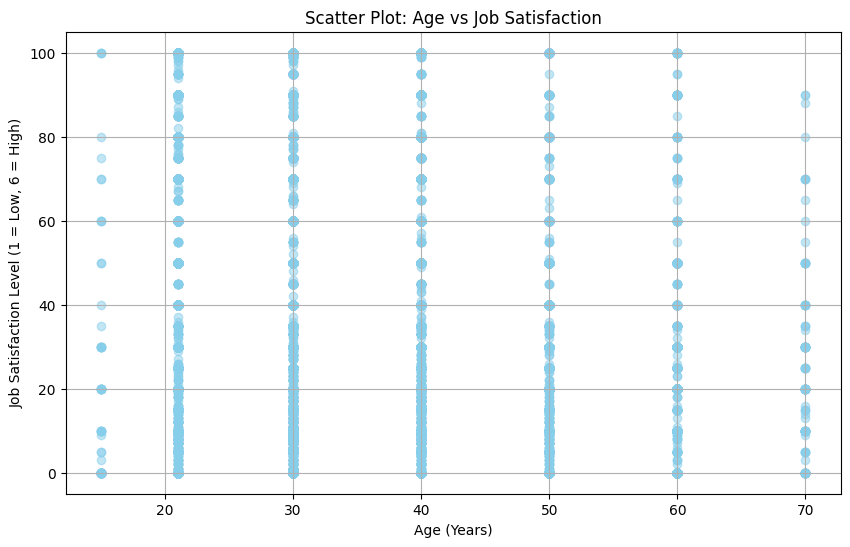

In [3]:
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

# Remove rows with missing age or JobSatPoints_6
df = df.dropna(subset=['Age_numeric', 'JobSatPoints_6'])

# -----------------------------
# Step 3: Ensure Job Satisfaction is Numeric
# -----------------------------
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
# Step 4: Scatter Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(df['Age_numeric'], df['JobSatPoints_6'], alpha=0.5, color='skyblue')
plt.title('Scatter Plot: Age vs Job Satisfaction')
plt.xlabel('Age (Years)')
plt.ylabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


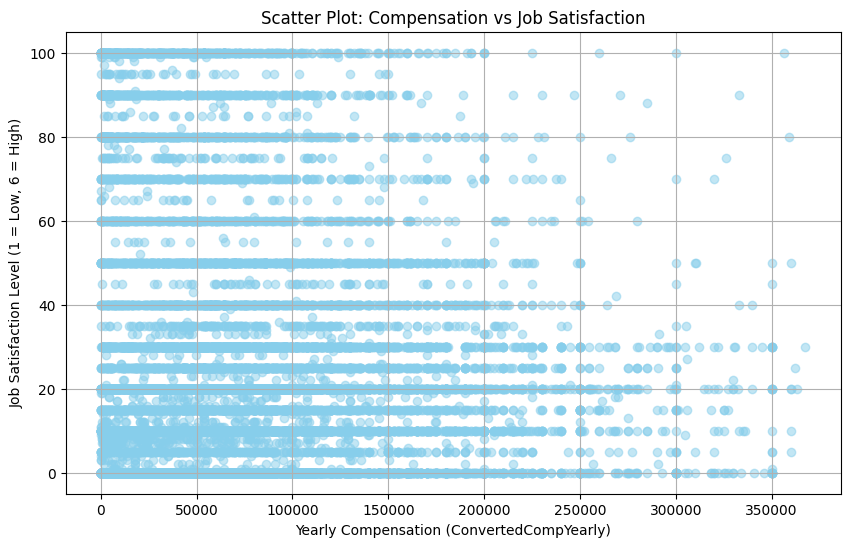

In [4]:
df = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'])

# Convert Job Satisfaction to numeric
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
# Step 3: Remove extreme compensation outliers (optional but recommended)
# -----------------------------
upper_limit = df['ConvertedCompYearly'].quantile(0.99)  # keep 99% of data
df_filtered = df[df['ConvertedCompYearly'] <= upper_limit]

# -----------------------------
# Step 4: Scatter Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(df_filtered['ConvertedCompYearly'], df_filtered['JobSatPoints_6'], alpha=0.5, color='skyblue')
plt.title('Scatter Plot: Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.grid(True)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


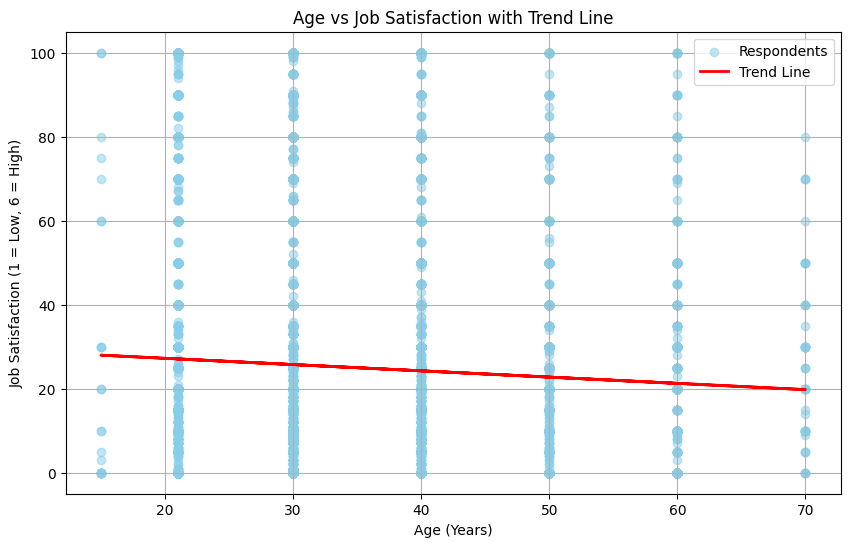

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

# Remove rows with missing Age or Job Satisfaction
df = df.dropna(subset=['Age_numeric', 'JobSatPoints_6'])

# Ensure JobSatPoints_6 is numeric
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
# Step 3: Scatter Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(df['Age_numeric'], df['JobSatPoints_6'], alpha=0.5, color='skyblue', label='Respondents')

# -----------------------------
# Step 4: Add Trend Line
# -----------------------------
# Fit linear regression
x = df['Age_numeric']
y = df['JobSatPoints_6']
m, b = np.polyfit(x, y, 1)  # slope and intercept

plt.plot(x, m*x + b, color='red', linewidth=2, label='Trend Line')

# -----------------------------
# Step 5: Finalize Plot
# -----------------------------
plt.title('Age vs Job Satisfaction with Trend Line')
plt.xlabel('Age (Years)')
plt.ylabel('Job Satisfaction (1 = Low, 6 = High)')
plt.legend()
plt.grid(True)
plt.show()


#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


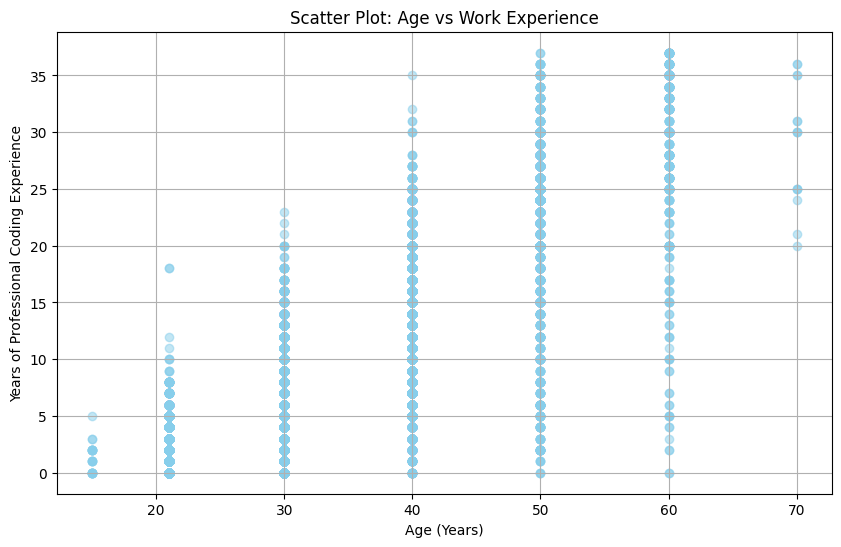

In [6]:
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)

# -----------------------------
# Step 3: Convert YearsCodePro to Numeric
# -----------------------------
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 50
})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# -----------------------------
# Step 4: Drop rows with missing values
# -----------------------------
df = df.dropna(subset=['Age_numeric', 'YearsCodePro'])

# -----------------------------
# Step 5: Remove extreme outliers (optional)
# -----------------------------
upper_limit = df['YearsCodePro'].quantile(0.99)
df_filtered = df[df['YearsCodePro'] <= upper_limit]

# -----------------------------
# Step 6: Scatter Plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(df_filtered['Age_numeric'], df_filtered['YearsCodePro'], alpha=0.5, color='skyblue')
plt.title('Scatter Plot: Age vs Work Experience')
plt.xlabel('Age (Years)')
plt.ylabel('Years of Professional Coding Experience')
plt.grid(True)
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


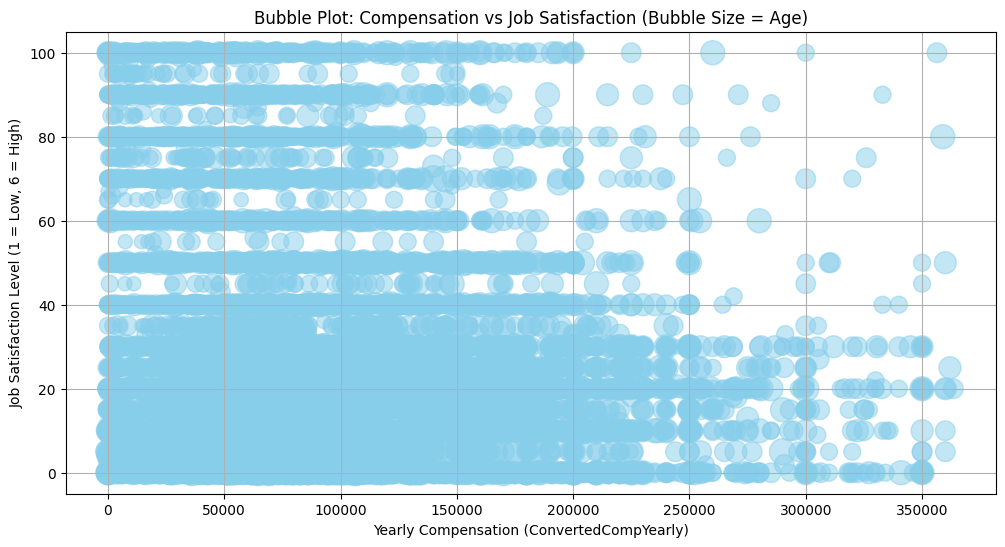

In [11]:
# -----------------------------
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)


# -----------------------------
upper_limit = df['ConvertedCompYearly'].quantile(0.99)
df = df[df['ConvertedCompYearly'] <= upper_limit]


# -----------------------------
plt.figure(figsize=(12,6))
plt.scatter(
    x=df['ConvertedCompYearly'],
    y=df['JobSatPoints_6'],
    s=df['Age_numeric']*5,  # Bubble size scaled by age
    alpha=0.5,
    color='skyblue'
)

plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


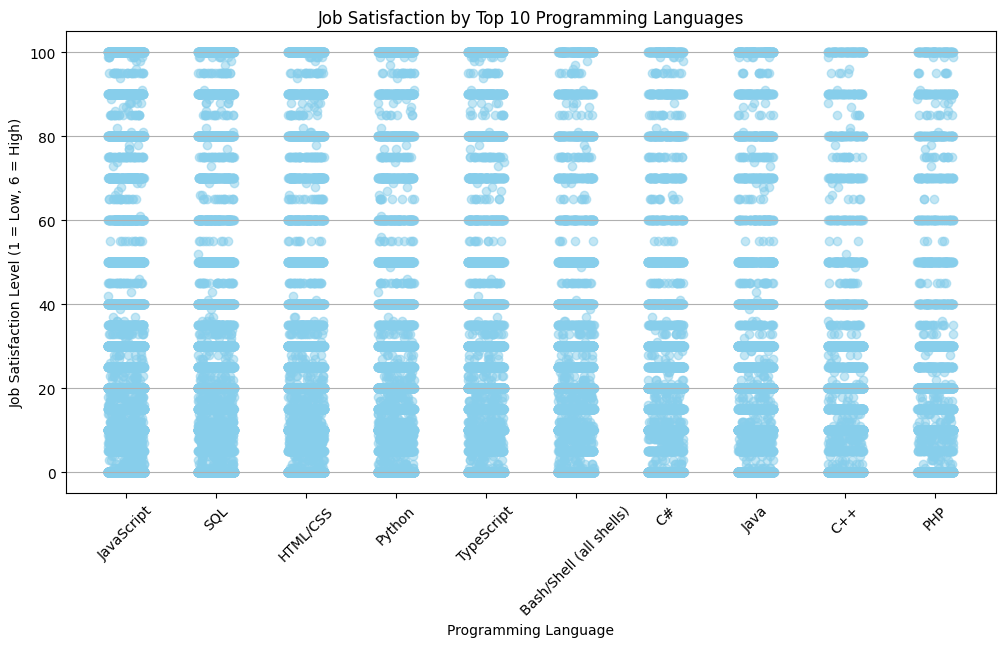

In [12]:
df = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6'])
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

rows = []
for _, row in df.iterrows():
    languages = row['LanguageHaveWorkedWith'].split(';')
    for lang in languages:
        rows.append({'Language': lang.strip(), 'JobSatPoints_6': row['JobSatPoints_6']})

df_lang = pd.DataFrame(rows)


top_langs = df_lang['Language'].value_counts().head(10).index.tolist()
df_top = df_lang[df_lang['Language'].isin(top_langs)]


plt.figure(figsize=(12,6))

# Use jitter for x-axis to separate points for each language
import numpy as np
x = [top_langs.index(lang) + np.random.uniform(-0.2, 0.2) for lang in df_top['Language']]
y = df_top['JobSatPoints_6']

plt.scatter(x, y, alpha=0.5, color='skyblue')

plt.xticks(range(len(top_langs)), top_langs, rotation=45)
plt.xlabel('Programming Language')
plt.ylabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.title('Job Satisfaction by Top 10 Programming Languages')
plt.grid(True, axis='y')
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


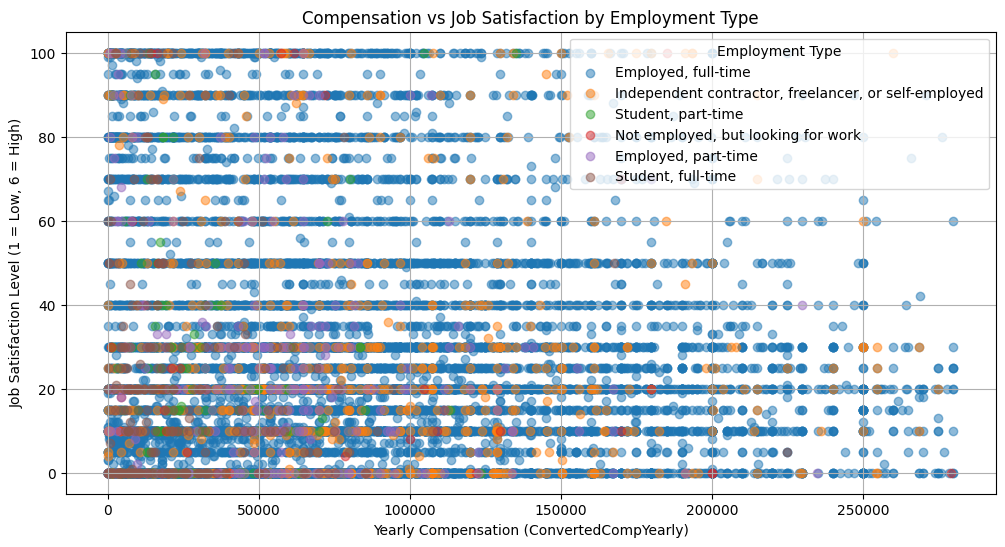

In [13]:
# -----------------------------
df = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Employment'])
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# -----------------------------
# Step 3: Clean Employment column
# (Take only the first employment type if multiple)
# -----------------------------
df['Employment'] = df['Employment'].apply(lambda x: x.split(';')[0])

# -----------------------------
# Step 4: Remove extreme compensation outliers (optional)
# -----------------------------
upper_limit = df['ConvertedCompYearly'].quantile(0.99)
df = df[df['ConvertedCompYearly'] <= upper_limit]

# -----------------------------
# Step 5: Scatter Plot with Color Coding
# -----------------------------
plt.figure(figsize=(12,6))

# Assign a color to each employment type
employment_types = df['Employment'].unique()
colors = plt.cm.tab10.colors  # Up to 10 colors
color_map = {emp: colors[i % len(colors)] for i, emp in enumerate(employment_types)}

for emp in employment_types:
    subset = df[df['Employment'] == emp]
    plt.scatter(
        subset['ConvertedCompYearly'],
        subset['JobSatPoints_6'],
        alpha=0.5,
        label=emp,
        color=color_map[emp]
    )

plt.title('Compensation vs Job Satisfaction by Employment Type')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction Level (1 = Low, 6 = High)')
plt.legend(title='Employment Type')
plt.grid(True)
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


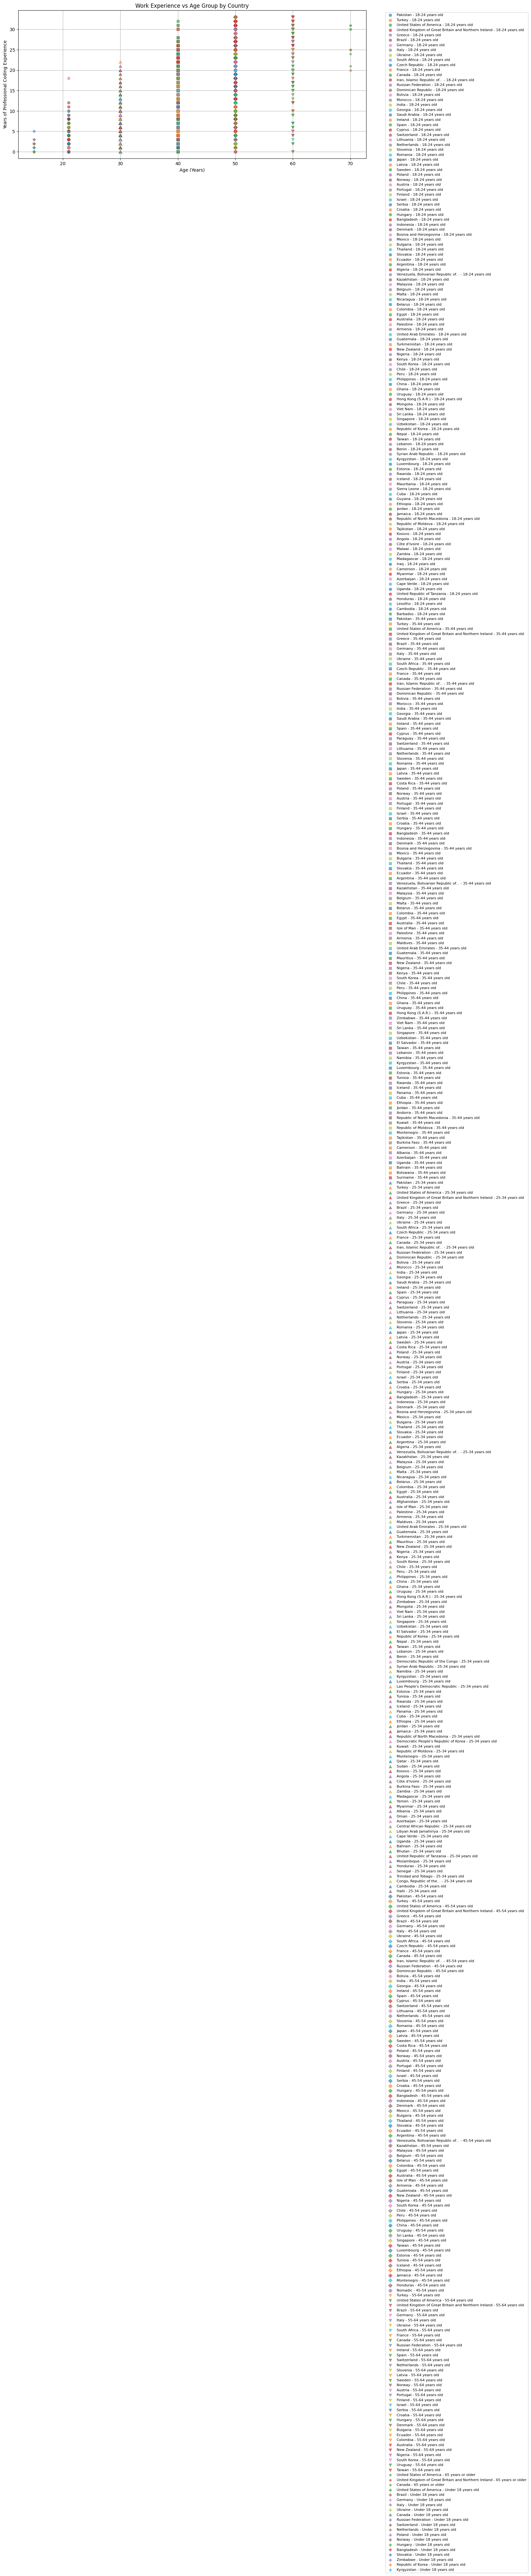

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# -----------------------------
# Step 2: Filter valid data
# -----------------------------
df = df.dropna(subset=['YearsCodePro', 'Age', 'Country'])

# -----------------------------
# Step 3: Convert YearsCodePro to numeric
# -----------------------------
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 50
})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df = df.dropna(subset=['YearsCodePro'])

# -----------------------------
# Step 4: Optionally filter extreme outliers
# -----------------------------
upper_limit = df['YearsCodePro'].quantile(0.99)
df = df[df['YearsCodePro'] <= upper_limit]

# -----------------------------
# Step 5: Map Age to numeric midpoints for plotting
# -----------------------------
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_numeric'] = df['Age'].map(age_mapping)

# -----------------------------
# Step 6: Prepare markers and colors
# -----------------------------
age_groups = df['Age'].unique()
markers = ['o', 's', '^', 'D', 'v', '*', 'P']  # Different markers for age groups
age_marker_map = {age: markers[i % len(markers)] for i, age in enumerate(age_groups)}

countries = df['Country'].unique()
colors = plt.cm.tab10.colors  # Up to 10 colors
country_color_map = {country: colors[i % len(colors)] for i, country in enumerate(countries)}

# -----------------------------
# Step 7: Scatter Plot
# -----------------------------
plt.figure(figsize=(14,6))

for age in age_groups:
    for country in countries:
        subset = df[(df['Age'] == age) & (df['Country'] == country)]
        if not subset.empty:
            plt.scatter(
                subset['Age_numeric'],
                subset['YearsCodePro'],
                alpha=0.6,
                marker=age_marker_map[age],
                color=country_color_map[country],
                label=f"{country} - {age}"
            )

plt.xlabel('Age (Years)')
plt.ylabel('Years of Professional Coding Experience')
plt.title('Work Experience vs Age Group by Country')
plt.grid(True)

# -----------------------------
# Step 8: Handle legend (remove duplicates)
# -----------------------------
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()


### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
